In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model
from tensorflow.keras import Sequential

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import img_to_array

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Project Configuration

In [3]:
# Configuration
IMAGE_SIZE = 300
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 47
SPLIT_NUMBER = 1
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration Loaded Successfully")
print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Split      : {SPLIT_NUMBER}")

Configuration Loaded Successfully
Image Size : 300
Batch Size : 32
Split      : 1


# Loading Dataset

In [4]:
DATASET_PATH = "/content/drive/MyDrive/dtd"
IMAGES_PATH = os.path.join(DATASET_PATH,"images")
LABELS_PATH = os.path.join(DATASET_PATH,"labels")

In [5]:
def read_split(split_file):
    image_paths = []
    labels = []

    with open(split_file, "r") as file:
        for line in file:
            relative_path = line.strip()
            label = relative_path.split("/")[0]
            absolute_path = os.path.join(IMAGES_PATH, relative_path)
            image_paths.append(absolute_path)
            labels.append(label)

    return image_paths, labels

In [6]:
# Read Label txt files to split the image dataset

train_images, train_labels = read_split(os.path.join(LABELS_PATH, "train1.txt"))

val_images, val_labels = read_split(os.path.join(LABELS_PATH, "val1.txt"))

test_images, test_labels = read_split(os.path.join(LABELS_PATH, "test1.txt"))

In [7]:
# Pninting no of images per class
print("Training Images   :", len(train_images))
print("Validation Images :", len(val_images))
print("Testing Images    :", len(test_images))

Training Images   : 1880
Validation Images : 1880
Testing Images    : 1880


## Create Dataframe of the Dataset

In [8]:
# Create DataFrames of the train, validation, test set images and of the final dataframe

train_df = pd.DataFrame({"filepath": train_images, "label": train_labels})

val_df = pd.DataFrame({"filepath": val_images, "label": val_labels})

test_df = pd.DataFrame({"filepath": test_images, "label": test_labels})

# final complete dataset as df
df_dtd = pd.concat([train_df, val_df, test_df],ignore_index=True)

print(df_dtd.head())

                                            filepath   label
0  /content/drive/MyDrive/dtd/images/banded/bande...  banded
1  /content/drive/MyDrive/dtd/images/banded/bande...  banded
2  /content/drive/MyDrive/dtd/images/banded/bande...  banded
3  /content/drive/MyDrive/dtd/images/banded/bande...  banded
4  /content/drive/MyDrive/dtd/images/banded/bande...  banded


# EDA

## Checking for any Missing Images

In [9]:
def check_missing(df_dtd):
    missing=[]
    for path in df_dtd["filepath"]:
        if not os.path.exists(path):
            missing.append(path)
    return missing


missing_train = check_missing(train_df)
missing_val = check_missing(val_df)
missing_test = check_missing(test_df)

print("Missing Train Images :",len(missing_train))
print("Missing Validation Images :",len(missing_val))
print("Missing Test Images :",len(missing_test))

Missing Train Images : 0
Missing Validation Images : 0
Missing Test Images : 0


## Dataset Statictics and Class Imbalance Checking

In [10]:
print("="*60)
print("DATASET STATISTICS")
print("="*60)

print("Training Images   :", len(train_images))
print("Validation Images :", len(val_images))
print("Testing Images    :", len(test_images))

print(f"Number of Classes : {train_df['label'].nunique()}")
print("\nClasses:")
print(sorted(train_df["label"].unique()))

DATASET STATISTICS
Training Images   : 1880
Validation Images : 1880
Testing Images    : 1880
Number of Classes : 47

Classes:
['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline', 'dotted', 'fibrous', 'flecked', 'freckled', 'frilly', 'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced', 'knitted', 'lacelike', 'lined', 'marbled', 'matted', 'meshed', 'paisley', 'perforated', 'pitted', 'pleated', 'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared', 'spiralled', 'sprinkled', 'stained', 'stratified', 'striped', 'studded', 'swirly', 'veined', 'waffled', 'woven', 'wrinkled', 'zigzagged']


In [11]:
# No of Images per Class
class_counts = train_df["label"].value_counts().sort_index()
display(class_counts.to_frame(name="Training Images"))

,Training Images
label,
banded,40
blotchy,40
braided,40
bubbly,40
bumpy,40
chequered,40
cobwebbed,40
cracked,40
crosshatched,40


## Printing One Image Per Texture Class

In [12]:
# Get one random sample image from every class

sample_per_class = train_df.groupby("label").sample(1, random_state = 42).reset_index(drop = True)

print(f"Number of Classes : {len(sample_per_class)}")

Number of Classes : 47


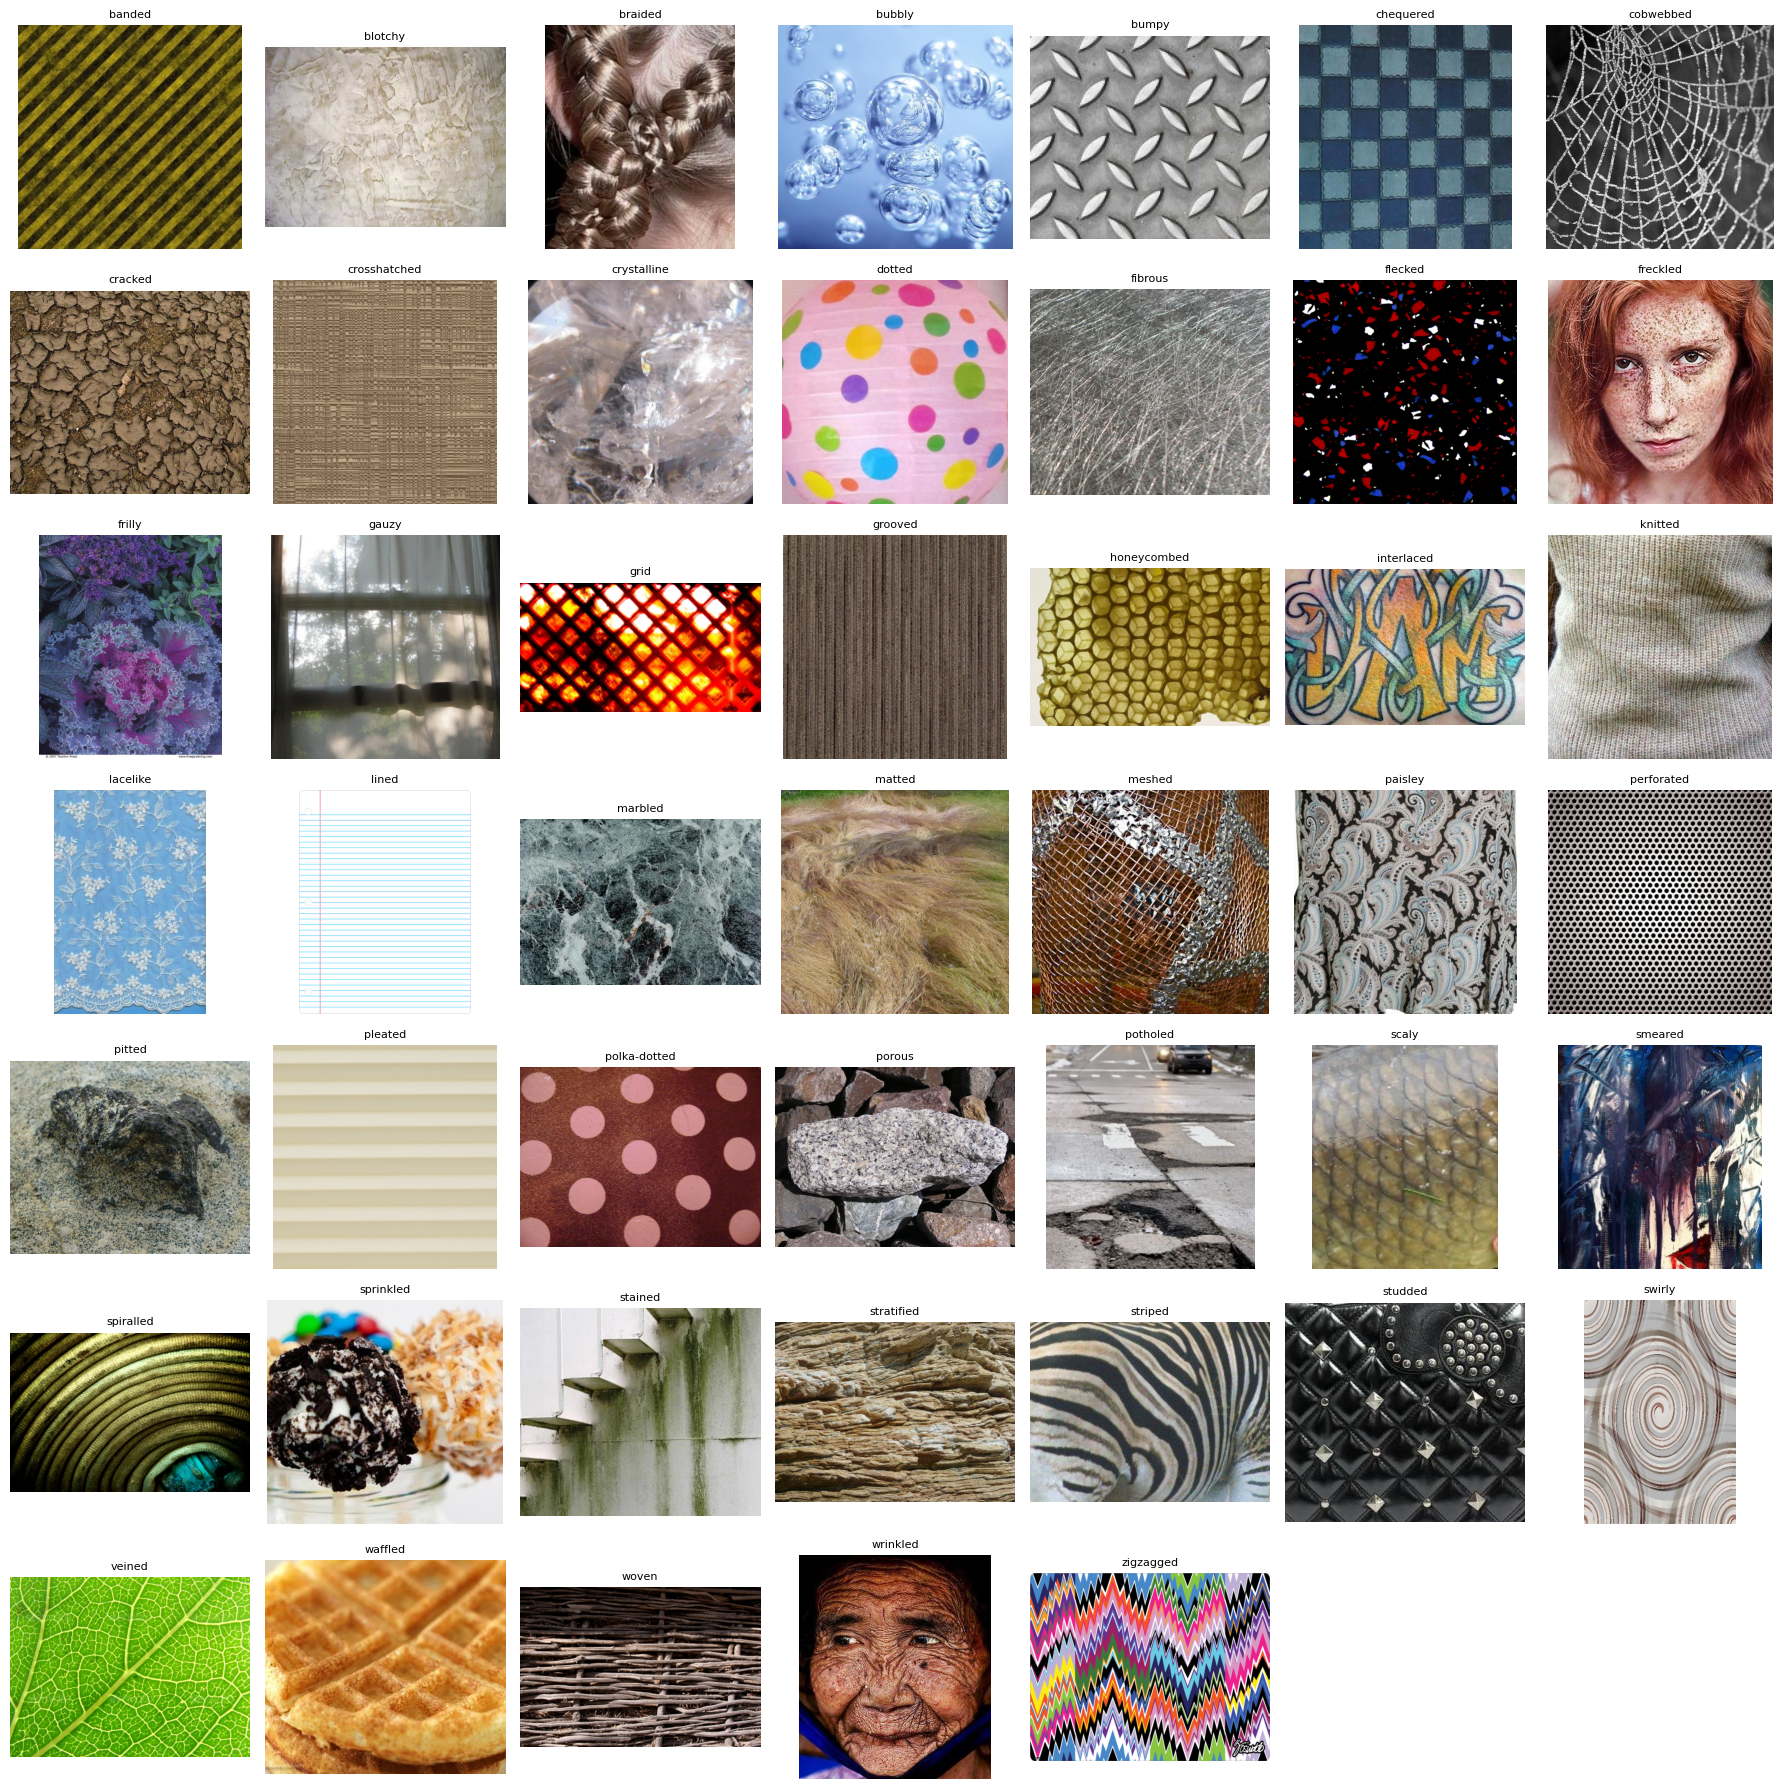

In [13]:
fig = plt.figure(figsize=(18,18))

for idx, row in sample_per_class.iterrows():
    img = cv2.imread(row["filepath"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(7,7,idx+1)
    plt.imshow(img)
    plt.title(row["label"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Checking random sample image

In [14]:
sample_path = train_df.sample(1, random_state=SEED).iloc[0]["filepath"]

print(sample_path)

/content/drive/MyDrive/dtd/images/perforated/perforated_0145.jpg


In [15]:
# Read the sample image

image_bgr = cv2.imread(sample_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(image_rgb.shape)

(541, 428, 3)


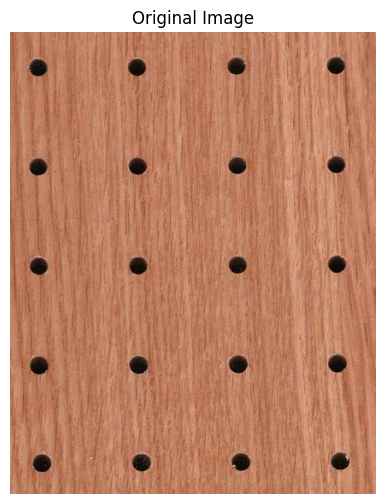

In [16]:
# Display Original Image

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Data Preprocessing

In [17]:
# Image preprocessing

def preprocess_image(image_path):
    # Read image
    image = cv2.imread(image_path)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize image
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Convert to float32
    image = image.astype(np.float32)

    # EfficientNet preprocessing
    image = preprocess_input(image)

    return image

## Label Encoding

In [18]:
# Texture class names are converted into integer labels for model training.
label_encoder = LabelEncoder()
label_encoder.fit(train_df["label"])

train_labels_encoded = label_encoder.transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

In [19]:
# printing no of class and all class names
NUM_CLASSES = len(label_encoder.classes_)
print("Number of classes:", NUM_CLASSES)
print(label_encoder.classes_)

Number of classes: 47
['banded' 'blotchy' 'braided' 'bubbly' 'bumpy' 'chequered' 'cobwebbed'
 'cracked' 'crosshatched' 'crystalline' 'dotted' 'fibrous' 'flecked'
 'freckled' 'frilly' 'gauzy' 'grid' 'grooved' 'honeycombed' 'interlaced'
 'knitted' 'lacelike' 'lined' 'marbled' 'matted' 'meshed' 'paisley'
 'perforated' 'pitted' 'pleated' 'polka-dotted' 'porous' 'potholed'
 'scaly' 'smeared' 'spiralled' 'sprinkled' 'stained' 'stratified'
 'striped' 'studded' 'swirly' 'veined' 'waffled' 'woven' 'wrinkled'
 'zigzagged']


In [20]:
# Checking train_labels encoded or not with type

print(train_labels_encoded[:5])
print(type(train_labels_encoded[0]))

[0 0 0 0 0]
<class 'numpy.int64'>


## Data Augmentation  
Data augmentation artificially increases training diversity without creating new image files.

Augmentation is applied **only during training**. Validation and test images remain unchanged.

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

# Final Configuration

In [22]:
print("=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)

print(f"Classes          : {NUM_CLASSES}")
print(f"Image Size       : {IMAGE_SIZE}")
print(f"Batch Size       : {BATCH_SIZE}")
print(f"Training Images  : {len(train_df)}")
print(f"Validation Images: {len(val_df)}")
print(f"Testing Images   : {len(test_df)}")

DATA PREPARATION COMPLETE
Classes          : 47
Image Size       : 300
Batch Size       : 32
Training Images  : 1880
Validation Images: 1880
Testing Images   : 1880


# Model Building - EfficientNet-B0


In [23]:
# Splitting images into train, test and validation dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels_encoded))
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels_encoded))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels_encoded))

In [24]:
# for loading images
def load_image(image_path, label):

    image = tf.numpy_function(
        preprocess_image,
        [image_path],
        tf.float32
    )

    image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))

    return image, label

In [25]:
train_dataset = train_dataset.map(load_image,
                                  num_parallel_calls = tf.data.AUTOTUNE)

val_dataset = val_dataset.map(load_image,
                              num_parallel_calls = tf.data.AUTOTUNE)

test_dataset = test_dataset.map(load_image,
                                num_parallel_calls = tf.data.AUTOTUNE)

In [26]:
train_dataset = train_dataset.shuffle(1000)\
                             .batch(BATCH_SIZE)\
                             .prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(BATCH_SIZE)\
                         .prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE)\
                           .prefetch(tf.data.AUTOTUNE)

## EfficientNet

In [27]:
# EfficientNetB0 is the base model. We use a pretrained model for training
base_model = EfficientNetB3(
    weights = 'imagenet',
    include_top = False,
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
# Making the pretrained weights false
base_model.trainable = False

In [29]:
# Model building

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation='relu',
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=l2(1e-4)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

In [30]:
# Get model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,716,958 (44.70 MB)

 Trainable params: 931,887 (3.55 MB)

 Non-trainable params: 10,785,071 (41.14 MB)

In [31]:
print("IMAGE_SIZE:", IMAGE_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)
print("Base Model:", base_model.name)

IMAGE_SIZE: 300
NUM_CLASSES: 47
Base Model: efficientnetb3


In [32]:
# compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# callbacks
checkpoint = ModelCheckpoint(
    "best_efficientnetb3.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = "max",
    verbose = 1
)

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 6,
    restore_best_weights = True
)

reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.2,
    patience = 3,
    min_lr = 1e-6,
    verbose = 1
)

In [34]:
# model training
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = 25,
    callbacks = [early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0607 - loss: 4.5476
Epoch 1: val_accuracy improved from None to 0.30904, saving model to best_efficientnetb3.keras

Epoch 1: finished saving model to best_efficientnetb3.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 869s 11s/step - accuracy: 0.1005 - loss: 4.1976 - val_accuracy: 0.3090 - val_loss: 3.4077 - learning_rate: 3.0000e-04
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3118 - loss: 2.8151
Epoch 2: val_accuracy improved from 0.30904 to 0.45319, saving model to best_efficientnetb3.keras

Epoch 2: finished saving model to best_efficientnetb3.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 531ms/step - accuracy: 0.3351 - loss: 2.7444 - val_accuracy: 0.4532 - val_loss: 2.8290 - learning_rate: 3.0000e-04
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4639 - loss: 2.1556
Epoch 3: val_accuracy improved from 0.45319 to 0.52926, saving model to best_efficientnetb3.keras

Epoch 3: finished saving model to best_e

In [35]:
# base model evaluation
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 391s 7s/step - accuracy: 0.6814 - loss: 1.2914
Test Loss: 1.2914
Test Accuracy: 0.6814


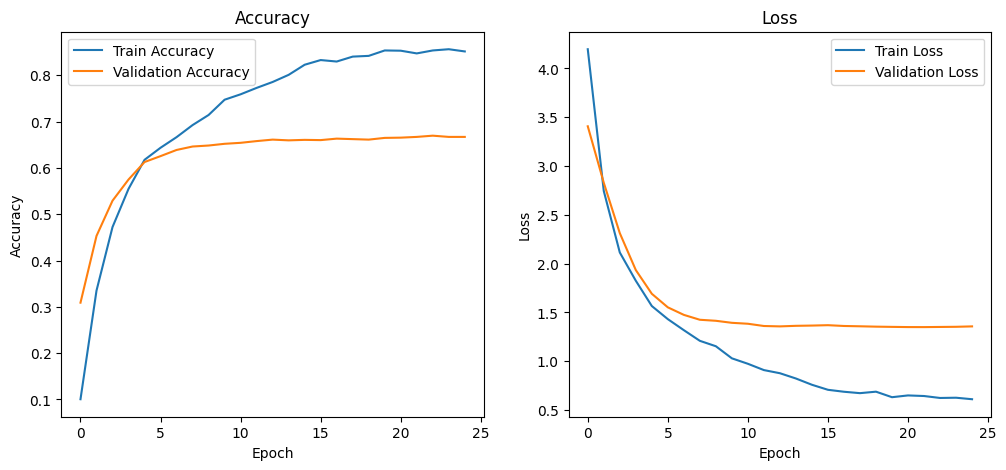

In [36]:
# Plotting model's performance
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [37]:
# Fine-tuning EfficientNetB3

# Unfreeze the EfficientNetB3 base model
base_model.trainable = True

# Freeze the lower layers and fine-tune only the top layers
fine_tune_at = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning callbacks
fine_tune_checkpoint = ModelCheckpoint(
    "best_efficientnetb3_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

fine_tune_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Fine-tune the model
fine_tune_history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=15,
    callbacks=[
        fine_tune_early_stop,
        fine_tune_reduce_lr,
        fine_tune_checkpoint
    ]
)

Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8451 - loss: 0.6713
Epoch 1: val_accuracy improved from None to 0.66383, saving model to best_efficientnetb3_finetuned.keras

Epoch 1: finished saving model to best_efficientnetb3_finetuned.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 70s 702ms/step - accuracy: 0.8580 - loss: 0.6290 - val_accuracy: 0.6638 - val_loss: 1.3465 - learning_rate: 1.0000e-05
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.8526 - loss: 0.6387
Epoch 2: val_accuracy did not improve from 0.66383
59/59 ━━━━━━━━━━━━━━━━━━━━ 3114s 54s/step - accuracy: 0.8569 - loss: 0.6033 - val_accuracy: 0.6622 - val_loss: 1.3460 - learning_rate: 1.0000e-05
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8471 - loss: 0.6291
Epoch 3: val_accuracy did not improve from 0.66383
59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 625ms/step - accuracy: 0.8707 - loss: 0.5851 - val_accuracy: 0.6601 - val_loss: 1.3376 - learning_rate: 1.0000e-05
Epoch 4/15
59/59 ━━━━━━━━━

In [40]:
# Load best fine-tuned model

model_fine_tuned = tf.keras.models.load_model("best_efficientnetb3_finetuned.keras")

In [41]:
# fine tuned model evaluation
test_loss, test_accuracy = model_fine_tuned.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.6973 - loss: 1.2403
Test Loss: 1.2403
Test Accuracy: 0.6973


# Evaluation

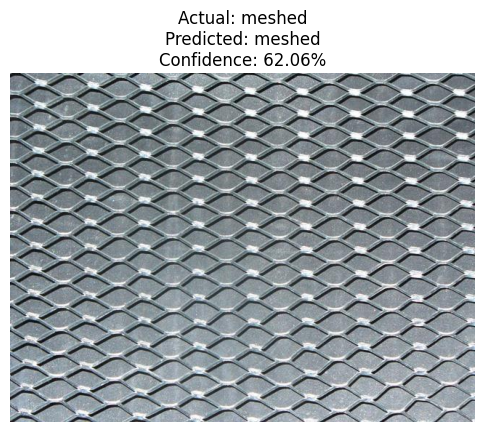

Image Path      : /content/drive/MyDrive/dtd/images/meshed/meshed_0186.jpg
Actual Class    : [25] meshed
Predicted Class : [25] meshed
Confidence      : 62.06%
Correct Prediction


In [49]:
# Randomly select one test image
idx = random.randint(0, len(test_images) - 1)

image_path = test_images[idx]

# Actual label
true_index = test_labels_encoded[idx]
true_label = test_labels[idx]

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Keep original image for display
display_image = image.copy()

# Preprocess image
image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
image = image.astype(np.float32)
image = preprocess_input(image)
image = np.expand_dims(image, axis=0)

# Predict
prediction = model.predict(image, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_label = label_encoder.classes_[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.axis("off")
plt.title(
    f"Actual: {true_label}\n"
    f"Predicted: {predicted_label}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

# Print results
print("=" * 60)
print("Image Path      :", image_path)
print(f"Actual Class    : [{true_index}] {true_label}")
print(f"Predicted Class : [{predicted_index}] {predicted_label}")
print(f"Confidence      : {confidence:.2f}%")



if true_index == predicted_index:
    print("Correct Prediction")
else:
    print("Incorrect Prediction")

# Inference

- The EfficientNetB0-based texture classification model achieved a test accuracy of 66.33% with a test loss of 1.3648. During training, the validation accuracy gradually improved and reached a best value of approximately 65.11%, indicating that the model learned meaningful texture features from the DTD dataset.

- The training accuracy increased to around 86.44%, while validation accuracy remained around 65%, showing a noticeable gap between training and validation performance. This suggests that the model has some degree of overfitting, although the use of dropout, L2 regularization, data augmentation, early stopping, and learning-rate reduction helped control it.

- Overall, the model provides moderate classification performance on the DTD dataset and demonstrates that EfficientNetB0 can effectively learn discriminative texture features.